In [32]:
import os
import pynwb
import h5py
from tqdm import tqdm
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import pywt
import matplotlib
import graph
import time
from itertools import product

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec

from scipy import signal
from scipy.fftpack import next_fast_len
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter1d
from scipy.signal import filtfilt, hilbert, remez, sosfiltfilt, butter, coherence, detrend
from scipy.stats import gaussian_kde
from joblib import Parallel, delayed

import load_data
import LFP
import graph

from fooof import FOOOF
from fooof import FOOOFGroup
from fooof import Bands
from fooof.plts.periodic import plot_peak_fits, plot_peak_params
from fooof.bands import Bands
from fooof.analysis import get_band_peak_fg, get_band_peak_fm
from fooof.plts.spectra import plot_spectra
from fooof.sim.gen import gen_aperiodic
from fooof.plts.aperiodic import plot_aperiodic_params, plot_aperiodic_fits

In [2]:
class AlphaDataset:
    
    def __init__(self, h5_path):
        self.f = h5py.File(h5_path, 'r')
        self.band_sig = self.f['band_sig']
        self.power = self.f['power']
        self.phase = self.f['phase']
        self.timestamps = self.f['timestamps']

    def get_trace(self, time):
        return self.band_sig[time, :].T, self.power[time, :].T, self.phase[time, :].T

    def get_band_sig(self, time):
        return self.band_sig[time, :]

    def get_power(self, time):
        return self.power[time, :]

    def get_phase(self, time):
        return self.phase[time, :]

    def close(self):
        self.f.close()

In [3]:
def epoch_aligned_lfp(date,df,window):

    timestamps, lfpData = load_data.load_LFP(date)
    
    num_ch = lfpData.shape[1]
    aligned_lfp = np.zeros((len(df),num_ch,window[1]-window[0])).astype(np.float32)
    
    for ii in range(len(df)):

        on = df.iloc[ii].t_on.astype(float)
        idx = (timestamps>on+window[0]) & (timestamps<on+window[1])
        aligned_lfp[ii,:,:] = LFP.preprocess_LFP(lfpData[idx,:].T.astype(np.float32)) 
    
    return aligned_lfp

In [4]:
def get_conditioned_flattened_psd(choice_df, action_aligned):

    # using fooof to extract periodic component
    
    n_trials = action_aligned.shape[0]
    nchannels = action_aligned.shape[1]
    psd = np.zeros((nchannels,n_trials,251))
    flat_spec = np.zeros((4,nchannels,50))
    ap_fit = np.zeros((4,nchannels,50))
    fg = FOOOFGroup()
    fm = FOOOF()
    
    for ch in tqdm(range(nchannels)):
        
        for trial in range(n_trials):
            psd_freqs, psd[ch,trial,:] = signal.welch(action_aligned[trial,ch,:], fs=1000, nperseg=500, noverlap=450)
        
        for vv in range(4):
            trial_idx = choice_df['value'].values==vv
            fm.fit(psd_freqs, psd[ch,trial_idx,:].mean(axis=0), [2, 100])
            init_ap_fit = gen_aperiodic(fm.freqs, fm._robust_ap_fit(fm.freqs, fm.power_spectrum))
            flat_spec[vv,ch,:] = fm.power_spectrum-init_ap_fit
            ap_fit[vv,ch,:] = init_ap_fit
            
    return fm.freqs, flat_spec

In [ ]:
# using fooof to get a distribution of peak frequency across trials for each channel
# then get the dominant peak frequency from each channel for all channels in Bart Plexon recording

for date in ['032823','033123','032023','040423','040723']:
    
    nwbfile = load_data.load_nwbfile('Bart',date) 
    
    query = 'trialerror==0'
    choice_df = nwbfile.intervals['action_on'].to_dataframe().query(query)
    choice_df['value'] = np.maximum(0,3-choice_df['graph_distance'].values)
    action_aligned = epoch_aligned_lfp(date,choice_df,[-250,750])
    
    dom_peaks = get_peak_frequency(action_aligned)

    temp = pd.DataFrame({'channel':np.arange(len(dom_peaks)),
                       'peak_freq':dom_peaks})
    temp['session']=date

    freq_df = pd.concat([freq_df,temp])

freq_df.to_pickle('D:/Alpha/peak_frequency_each_channel.pkl')
# pd.read_pickle('D:/Alpha/peak_frequency_each_channel.pkl')

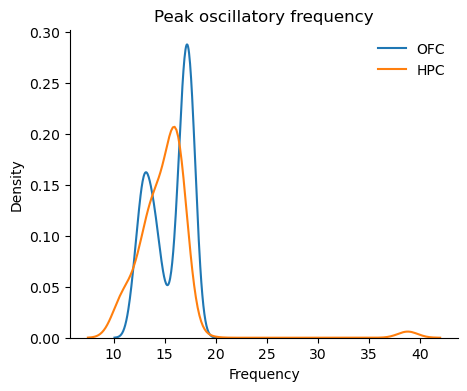

In [71]:
# plot peak frequency distribution across channels and sessions

plt.close('all')
plt.figure(figsize=(5,4))
# sns.histplot(data=freq_df,x='peak_freq')
sns.kdeplot(data=freq_df.query('channel<96'),x='peak_freq',label='OFC')
sns.kdeplot(data=freq_df.query('channel>95'),x='peak_freq',label='HPC')

sns.despine()
plt.title('Peak oscillatory frequency')
plt.xlabel('Frequency')
plt.legend(frameon=False)
plt.savefig('D:/Alpha/Peak oscillatory frequency')

In [ ]:
freq_df

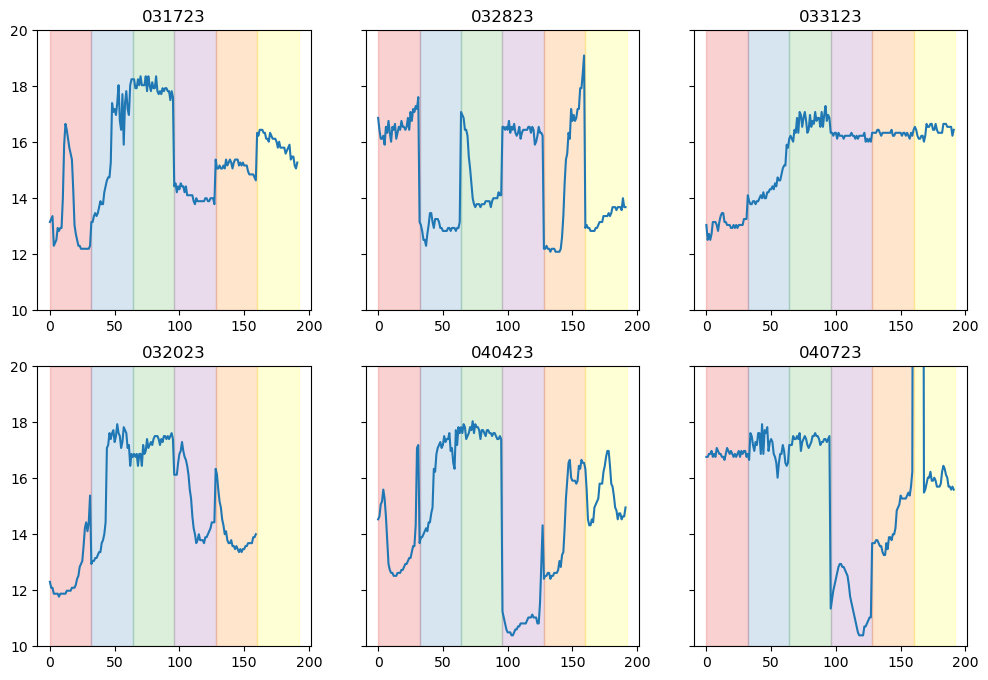

In [39]:
# # plot peak frequency along channels for each session

plt.close('all')
fig, axes = plt.subplots(2,3,figsize=(12,8),sharey=True)
dates = ['031723','032823','033123','032023','040423','040723']
colors = sns.color_palette('Set1',6)

for ss in range(6):
    r,c = np.divmod(ss,3)
    dom_peaks = freq_df[freq_df.session==dates[ss]].peak_freq.values
    
    for ii in range(6):
        axes[r,c].axvspan(ii*32,(ii+1)*32,color=colors[ii],alpha=0.2)
    axes[r,c].plot(dom_peaks)
    axes[r,c].set_ylim(10,20)
    axes[r,c].set_title(dates[ss])

In [25]:
def _process_channel(ch, action_aligned, fs=1000):

# get peak frequency distribution across trials for each channel
    
    n_trials = action_aligned.shape[0]

    fg = FOOOFGroup(
        peak_width_limits=[1.5, 10],
        max_n_peaks=3,
        min_peak_height=0.1,
        verbose=False
    )

    psds = []
    for trial in range(n_trials):
        freqs, psd = signal.welch(
            action_aligned[trial, ch, :],
            fs=fs,
            nperseg=500,
            noverlap=450
        )
        psds.append(psd)

    psds = np.asarray(psds)

    fg.fit(freqs, psds, [2, 55])
    peaks = fg.get_params('peak_params')

    if len(peaks) == 0:
        return np.nan

    kde = gaussian_kde(peaks[:, 0])
    x = np.linspace(2, 55, 500)
    y = kde(x)

    return x[np.argmax(y)]


def get_peak_frequency(action_aligned, fs=1000, n_jobs=-1):
    _, nchannels, _ = action_aligned.shape

    dominant_peaks = Parallel(n_jobs=n_jobs)(
        delayed(_process_channel)(ch, action_aligned)
        for ch in range(nchannels)
    )

    return np.array(dominant_peaks)


In [140]:
def plot_sem(time, trace, ax, ii, label, colors = 'Blues_r'):

    colors = sns.color_palette(colors,4)
    mean_trace = trace.mean(axis=0)
    sem_trace = trace.std(axis=0)/np.sqrt(trace.shape[0])
    ax.plot(time, mean_trace, color=colors[ii], label=label)
    ax.fill_between(time,
                    mean_trace - sem_trace,
                    mean_trace + sem_trace,
                    color=colors[ii],
                    alpha=0.3)

In [521]:
date = '031723'
flat_spec = np.load(f'D:/Alpha/Session {date} fooof flat psd.npy')
ch = np.argmax(np.max(flat_spec,axis=1))

In [ ]:
nwbfile = load_data.load_nwbfile('Bart',date) 
df = nwbfile.intervals['action_on'].to_dataframe()
node_df = nwbfile.intervals['node_on'].to_dataframe()
df['RT'] = df.t_on - node_df.t_on

In [523]:
np.argsort(np.max(flat_spec,axis=1))

array([182, 181, 180, 183, 179, 184, 185, 186, 190, 187, 178, 188, 189,
       191, 175, 177, 176, 134, 132, 133, 135,  18, 129, 136, 139, 131,
       142, 140, 130, 137, 174, 138, 141, 128, 173, 149, 143, 172, 170,
       144, 171, 169, 148, 168,  19, 145,   3, 167,   4, 146,   2,  17,
       150, 147,  20, 151, 165, 166, 160, 152,   5, 164, 163, 153, 161,
       162, 154, 155,  92,  16,  21,  91,  93,  57,  58, 156,   6,  94,
         1,  60,  59,  97, 157,  95,  96, 100,  98, 101, 102,  61, 158,
       103,  99, 104,  90,  56, 105, 159,  15, 106,  89,  62,  63,   7,
        88, 107, 108,  22,  87, 109,  86,  14,  85, 110,  83,  84,  81,
         8,  80,  13,  82, 116, 111,   0,  12, 112,  55,  79,   9,  78,
        77, 113,  11,  76,  10, 114,  75, 115,  74,  23,  72,  73, 117,
        71,  68,  70,  69, 118,  65,  67,  66, 119,  64,  24,  54, 120,
       121, 122,  25, 123,  26, 124, 125, 126,  53, 127,  27,  28,  31,
        30,  29,  52,  51,  50,  39,  46,  49,  48,  40,  41,  4

In [283]:
reward_df = nwbfile.intervals['reward_on'].to_dataframe()

In [ ]:
# get spectrogram aligned to action on
aligned_lfp = epoch_aligned_lfp(date,df,[-1000,1500])

wave_power = np.zeros((len(df),98,2500))
for trial in tqdm(range(len(df))):
    wave_freqs, _, wave_power[trial,:] = wavelet_spectrogram(aligned_lfp[trial,:],np.arange(2,100))

# average across time and trial to get fooof estimate of 1/f
fm = FOOOF()
fm.fit(wave_freqs, wave_power.mean(axis=(0,2)), [2, 100])
init_ap_fit = gen_aperiodic(fm.freqs, fm._robust_ap_fit(fm.freqs, fm.power_spectrum))
flat_spec = fm.power_spectrum-init_ap_fit

out = np.tile(init_ap_fit[:, None], (1, 2500))

In [259]:
# get spectrogram aligned to node on
aligned_lfp = epoch_aligned_lfp(date,node_df,[-1000,1500])

node_wave_power = np.zeros((len(node_df),98,2500))
for trial in tqdm(range(len(node_df))):
    wave_freqs, _, node_wave_power[trial,:] = wavelet_spectrogram(aligned_lfp[trial,:],np.arange(2,100))

# average across time and trial to get fooof estimate of 1/f
fm = FOOOF()
fm.fit(wave_freqs, node_wave_power.mean(axis=(0,2)), [2, 100])
init_ap_fit = gen_aperiodic(fm.freqs, fm._robust_ap_fit(fm.freqs, fm.power_spectrum))
flat_spec = fm.power_spectrum-init_ap_fit

node_out = np.tile(init_ap_fit[:, None], (1, 2500))

100%|██████████| 1727/1727 [02:05<00:00, 13.72it/s]



FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 1.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



In [519]:
aligned_lfp_OFC = epoch_aligned_lfp(date,reward_df,[0,1500],45)

In [576]:
aligned_lfp_OFC.shape

(720, 1500)

In [524]:
aligned_lfp_HPC = epoch_aligned_lfp(date,reward_df,[0,1500],127)

In [578]:
SXX = np.zeros((aligned_lfp_OFC.shape[0],38,1500))
SYY = np.zeros((aligned_lfp_OFC.shape[0],38,1500))
SXY = np.zeros((aligned_lfp_OFC.shape[0],38,1500),dtype=complex)

for trial in range(aligned_lfp_OFC.shape[0]):
    
    _, ofc_coef, _, _ = wavelet_spectrogram(aligned_lfp_OFC[trial,:],np.arange(2,40))
    _, hpc_coef, _, _ = wavelet_spectrogram(aligned_lfp_HPC[trial,:],np.arange(2,40))
    
    for tt in range(ofc_coef.shape[1]):
    
        xf = hpc_coef[:,tt]
        yf = ofc_coef[:,tt]
        SXX[trial,:,tt] = np.real(xf*np.conj(xf))
        SYY[trial,:,tt] = np.real(yf*np.conj(yf))
        SXY[trial,:,tt] = xf*np.conj(yf)  

In [585]:
#ofc_hpc_coh = np.zeros(ofc_coef.shape)
ofc_hpc_spec = np.zeros(ofc_coef.shape)
for tt in range(ofc_coef.shape[1]):
    ofc_hpc_spec[:,tt] = np.abs(SXY.mean(axis=0)[:,tt])
    #ofc_hpc_coh[:,tt] = np.abs(SXY.mean(axis=0)[:,tt])/ np.sqrt(SYY.mean(axis=0)[:,tt]) / np.sqrt(SXX.mean(axis=0)[:,tt])            # Cross spectrum
# ofc_hpc_phase[:,tt] = np.angle(SXY)

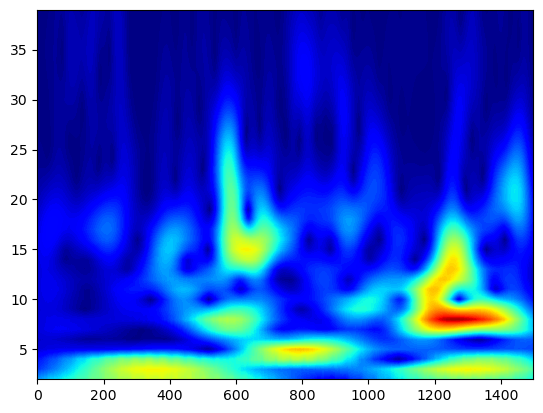

In [616]:
plt.close('all')
levels = np.linspace(0, 0.05, 100)
plt.contourf(
    np.arange(1500),
    np.arange(2,40),
    np.abs(SXY[2,:,:]),
    levels=levels,
    cmap='jet',
    extend='both'
)

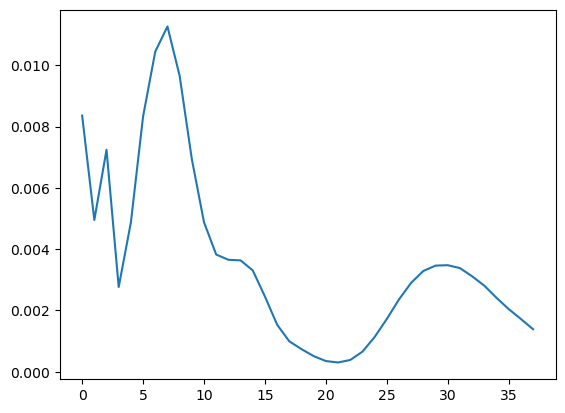

In [598]:
plt.plot(np.abs(SXY[0,:,600]))

Text(0.5, 0, 'Time (s)')

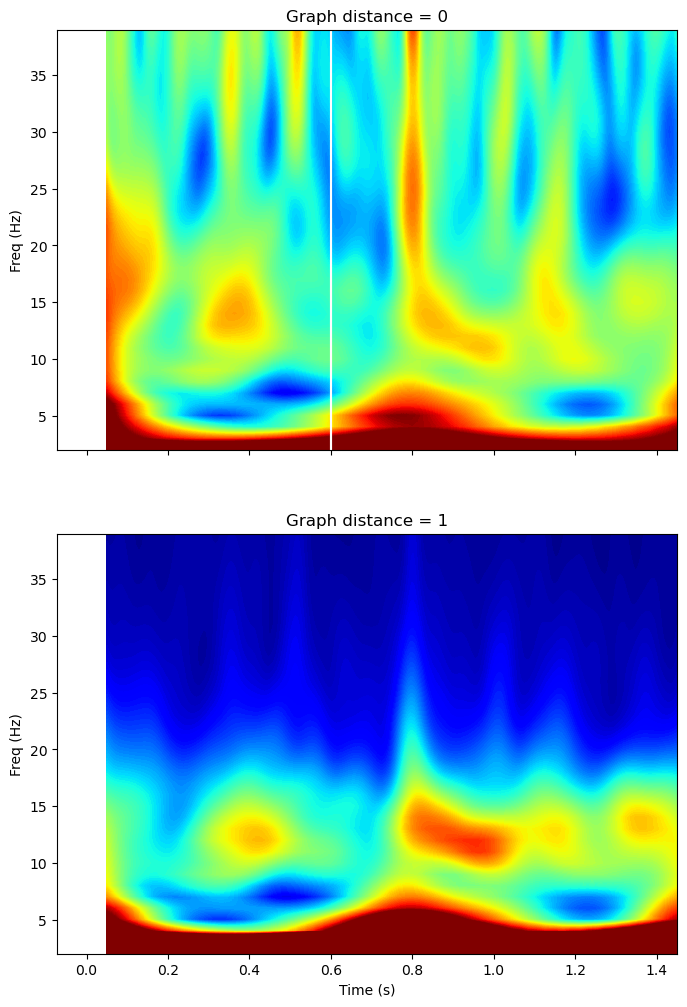

In [589]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12), sharex=True, sharey=True)

levels = np.linspace(0, 0.3, 100)
time = np.linspace(0.05, 1.45, 1400)
tt=np.arange(50,1450)

ii=0

c0 = axes[ii].contourf(
    time,
    np.arange(2,40),
    ofc_hpc_coh[:,tt],
    levels=levels,
    cmap='jet',
    extend='both'
)

axes[ii].set_title(f'Graph distance = {ii}')
axes[ii].set_ylabel('Freq (Hz)')
axes[ii].axvline(0,color='w')

axes[0].axvline(0.6,color='w')


levels = np.linspace(0, 0.005, 100)
ii = 1
c0 = axes[ii].contourf(
    time,
    np.arange(2,40),
    ofc_hpc_spec[:,tt],
    levels=levels,
    cmap='jet',
    extend='both'
)

axes[ii].set_title(f'Graph distance = {ii}')
axes[ii].set_ylabel('Freq (Hz)')
axes[ii].axvline(0,color='w')

axes[0].axvline(0.6,color='w')

axes[-1].set_xlabel('Time (s)')

# 🔥 create colorbar axis OUTSIDE
# cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
# # [left, bottom, width, height]

# cbar = fig.colorbar(c0, cax=cbar_ax)
# cbar.set_label('Power (1/f corrected)')

# # leave space for colorbar
# plt.suptitle('Action on')
# plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.savefig('D:/Beta/spectrogram_action_on_value.png')

In [286]:
# get spectrogram aligned to reward on
aligned_lfp = epoch_aligned_lfp(date,reward_df,[0,1500],45)

reward_wave_power = np.zeros((len(reward_df),98,1500))
for trial in tqdm(range(len(reward_df))):
    wave_freqs, _, reward_wave_power[trial,:] = wavelet_spectrogram(aligned_lfp[trial,:],np.arange(2,100))

# average across time and trial to get fooof estimate of 1/f
fm = FOOOF()
fm.fit(wave_freqs, reward_wave_power.mean(axis=(0,2)), [2, 100])
init_ap_fit = gen_aperiodic(fm.freqs, fm._robust_ap_fit(fm.freqs, fm.power_spectrum))
flat_spec = fm.power_spectrum-init_ap_fit

reward_out = np.tile(init_ap_fit[:, None], (1, 1500))

100%|██████████| 720/720 [00:31<00:00, 22.64it/s]



FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 1.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.



In [ ]:
fix_df = nwbfile.intervals['fixations'].to_dataframe()

fix_df['planning']=(fix_df.duration>50) & (fix_df.duration<300) & (fix_df.active_prob<0.2)

planning_df = fix_df.query('planning')

aligned_lfp = epoch_aligned_lfp(date,planning_df,[-1000,1500])

plan_wave_power = np.zeros((len(planning_df),98,2500))
for trial in tqdm(range(len(planning_df))):
    wave_freqs, _, plan_wave_power[trial,:] = wavelet_spectrogram(aligned_lfp[trial,:],np.arange(2,100))

# average across time and trial to get fooof estimate of 1/f
fm = FOOOF()
fm.fit(wave_freqs, plan_wave_power.mean(axis=(0,2)), [2, 100])
init_ap_fit = gen_aperiodic(fm.freqs, fm._robust_ap_fit(fm.freqs, fm.power_spectrum))
flat_spec = fm.power_spectrum-init_ap_fit

plan_out = np.tile(init_ap_fit[:, None], (1, 2500))

C:\Users\Admin\AppData\Local\Temp\ipykernel_32396\746279445.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


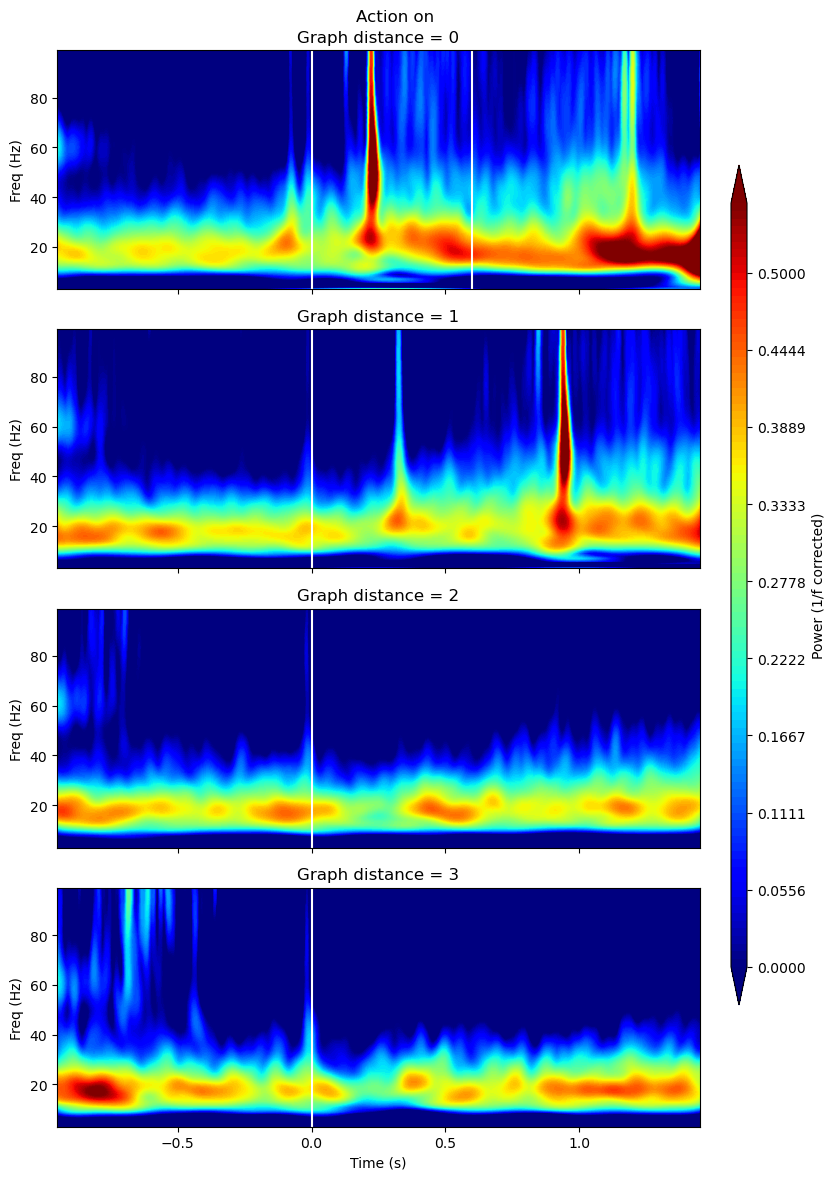

In [422]:
fig, axes = plt.subplots(4, 1, figsize=(8, 12), sharex=True, sharey=True)

levels = np.linspace(cmin, cmax, 100)
time = np.linspace(-0.95, 1.45, 2400)
tt=np.arange(50,2450)
idx = (wave_freqs>2) & (wave_freqs<100)

for ii in range(4):
    
    trial_idx = (df.trialerror == 0) & (df.graph_distance == ii)
    data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
    
    c0 = axes[ii].contourf(
        time,
        wave_freqs[idx],
        data,
        levels=levels,
        cmap='jet',
        extend='both'
    )
    
    axes[ii].set_title(f'Graph distance = {ii}')
    axes[ii].set_ylabel('Freq (Hz)')
    axes[ii].axvline(0,color='w')

axes[0].axvline(0.6,color='w')
axes[-1].set_xlabel('Time (s)')

# 🔥 create colorbar axis OUTSIDE
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(c0, cax=cbar_ax)
cbar.set_label('Power (1/f corrected)')

# leave space for colorbar
plt.suptitle('Action on')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('D:/Beta/spectrogram_action_on_value.png')

C:\Users\Admin\AppData\Local\Temp\ipykernel_32396\3488520082.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


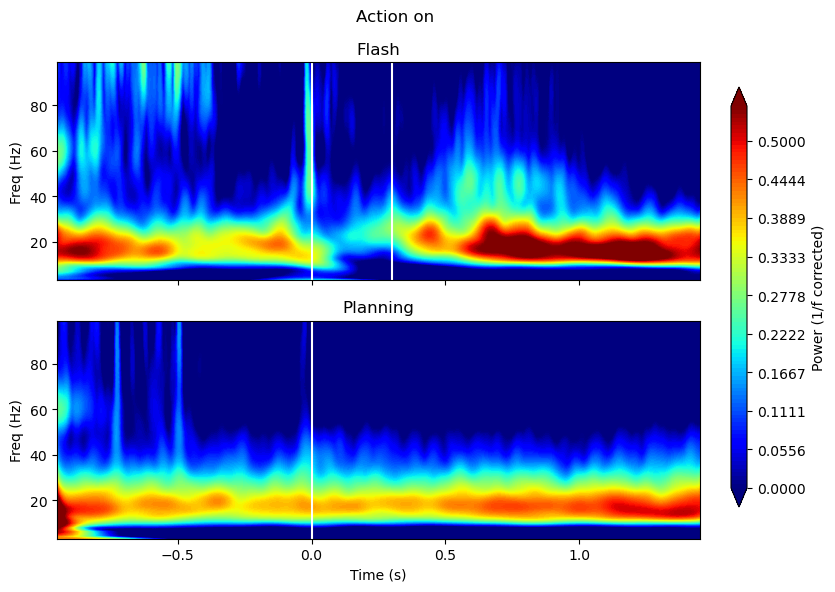

In [421]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, sharey=True)

idx = (wave_freqs>2) & (wave_freqs<100)
tt = np.arange(50,2450)

# flash
trial_idx = df.trialerror == 1
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]

c0 = axes[0].contourf(
    time,
    wave_freqs[idx],
    data,
    levels=levels,
    cmap='jet',
    extend='both'
)

axes[0].set_title('Flash')
axes[0].set_ylabel('Freq (Hz)')
axes[0].axvline(0,color='w')
axes[0].axvline(0.3,color='w')


# planning
data = (np.log10(plan_wave_power.mean(axis=0)) - plan_out)[idx,:][:,tt]

c0 = axes[1].contourf(
    time,
    wave_freqs[idx],
    data,
    levels=levels,
    cmap='jet',
    extend='both'
)

axes[1].set_title('Planning')
axes[1].set_ylabel('Freq (Hz)')
axes[1].axvline(0,color='w')

axes[-1].set_xlabel('Time (s)')

# 🔥 create colorbar axis OUTSIDE
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(c0, cax=cbar_ax)
cbar.set_label('Power (1/f corrected)')

# leave space for colorbar
plt.suptitle('Action on')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('D:/Beta/spectrogram_action_on_flash_planning.png')

C:\Users\Admin\AppData\Local\Temp\ipykernel_32396\3940253508.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


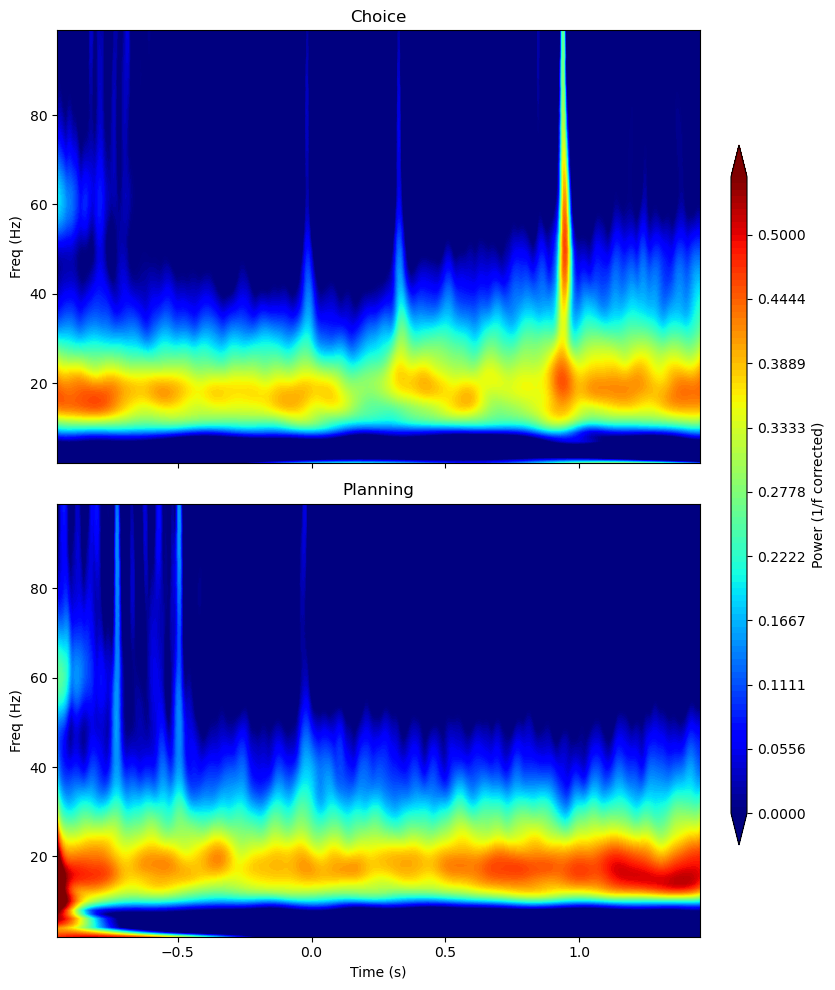

In [187]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True, sharey=True)

levels = np.linspace(cmin, cmax, 100)
time = np.linspace(-0.95, 1.45, 2400)

trial_idx = (df.trialerror == 0) & (df.graph_distance>0)
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]

c0 = axes[0].contourf(
    time,
    wave_freqs[idx],
    data,
    levels=levels,
    cmap='jet',
    extend='both'
)

axes[0].set_title('Choice')
axes[0].set_ylabel('Freq (Hz)')


# planning
data = (np.log10(plan_wave_power.mean(axis=0)) - plan_out)[idx,:][:,tt]

c0 = axes[1].contourf(
    time,
    wave_freqs[idx],
    data,
    levels=levels,
    cmap='jet',
    extend='both'
)

axes[1].set_title('Planning')
axes[1].set_ylabel('Freq (Hz)')


axes[-1].set_xlabel('Time (s)')

# 🔥 create colorbar axis OUTSIDE
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(c0, cax=cbar_ax)
cbar.set_label('Power (1/f corrected)')

# leave space for colorbar
plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.savefig('D:/Beta/spectrogram.png')

In [324]:
flat_reward_power = np.log10(reward_wave_power.mean(axis=2)) - reward_out.mean(axis=1)

In [327]:
idx = (wave_freqs>8) & (wave_freqs<25)

ITI_alpha_beta = flat_reward_power[:,idx].mean(axis=1)

In [340]:
reward_df['RT'] = df[df.step==0].RT

In [346]:
reward_df['beta_power'] = ITI_alpha_beta

In [343]:
reward_df['preceding_beta_power'] = np.concatenate(([np.nan], ITI_alpha_beta[:-1]))

<Axes: xlabel='preceding_beta_power', ylabel='RT'>

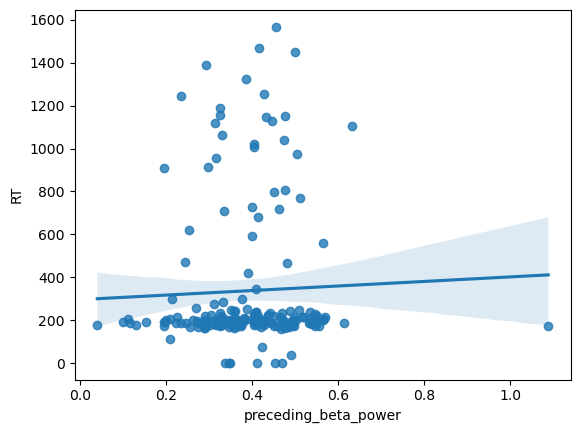

In [347]:
plt.close('all')
sns.regplot(data=reward_df.query('trialerror==0'),x='preceding_beta_power',y='RT')

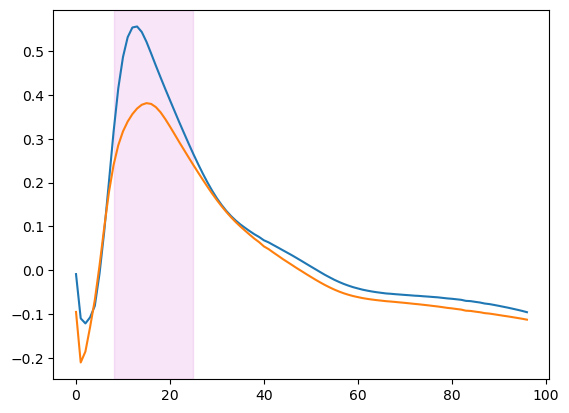

In [301]:

trial_idx = (reward_df.trialerror == 0) 
tt = np.arange(50,1450)
data = (np.log10(reward_wave_power[trial_idx,:].mean(axis=0)) - reward_out)[idx,:][:,tt]
plt.plot(data.mean(axis=1),label='ITI')

plt.axvspan(8,25,alpha=0.1,color='m')

tt = np.arange(50,2450)
trial_idx = (df.trialerror == 0) & (df.graph_distance>0)
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
plt.plot(data.mean(axis=1),label='trial')


C:\Users\Admin\AppData\Local\Temp\ipykernel_32396\3097038773.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


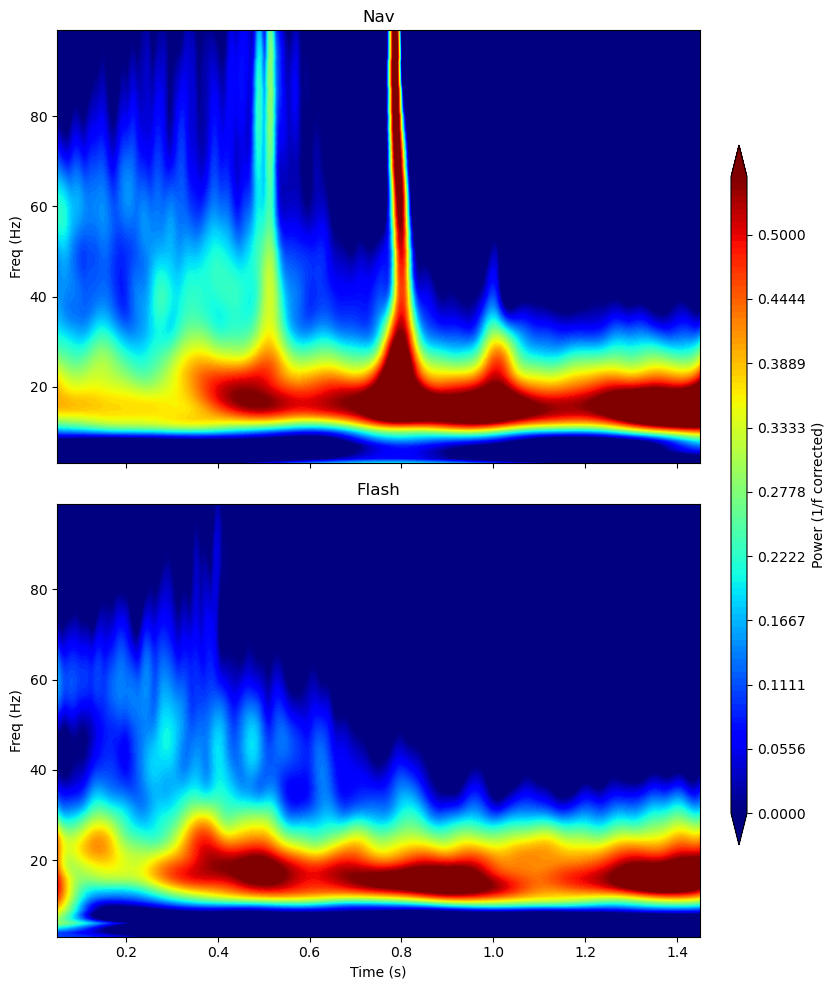

In [352]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True, sharey=True)


levels = np.linspace(cmin, cmax, 100)
time = np.linspace(0.05, 1.45, 1400)
tt = np.arange(50,1450)
idx = (wave_freqs>2) & (wave_freqs<100)

trial_idx = (reward_df.trialerror == 0) 
data = (np.log10(reward_wave_power[trial_idx,:].mean(axis=0)) - reward_out)[idx,:][:,tt]

c0 = axes[0].contourf(
    time,
    wave_freqs[idx],
    data,
    levels=levels,
    cmap='jet',
    extend='both'
)

axes[0].set_title('Nav')
axes[0].set_ylabel('Freq (Hz)')



trial_idx = (reward_df.trialerror == 1) 
data = (np.log10(reward_wave_power[trial_idx,:].mean(axis=0)) - reward_out)[idx,:][:,tt]

c0 = axes[1].contourf(
    time,
    wave_freqs[idx],
    data,
    levels=levels,
    cmap='jet',
    extend='both'
)

axes[1].set_title('Flash')
axes[1].set_ylabel('Freq (Hz)')


axes[-1].set_xlabel('Time (s)')

# 🔥 create colorbar axis OUTSIDE
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
# [left, bottom, width, height]

cbar = fig.colorbar(c0, cax=cbar_ax)
cbar.set_label('Power (1/f corrected)')

# leave space for colorbar
plt.tight_layout(rect=[0, 0, 0.9, 1])
# plt.savefig('D:/Beta/spectrogram.png')

In [209]:
def plot_sem(time, trace, ax, label, color):

    mean_trace = trace.mean(axis=0)
    sem_trace = trace.std(axis=0)/np.sqrt(trace.shape[0])
    ax.plot(time, mean_trace, color=color, label=label)
    ax.fill_between(time,
                    mean_trace - sem_trace,
                    mean_trace + sem_trace,
                    color=color,
                    alpha=0.3)

<Axes: xlabel='RT', ylabel='Count'>

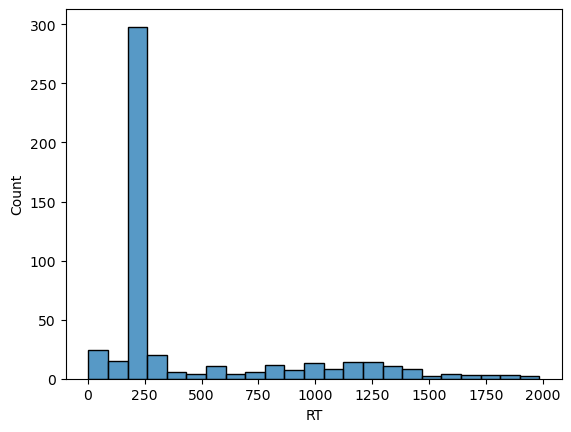

In [267]:
sns.histplot(data=df[(df.trialerror == 0) & (df.step==0)],x='RT')

In [279]:
idx = (wave_freqs>10) & (wave_freqs<22)


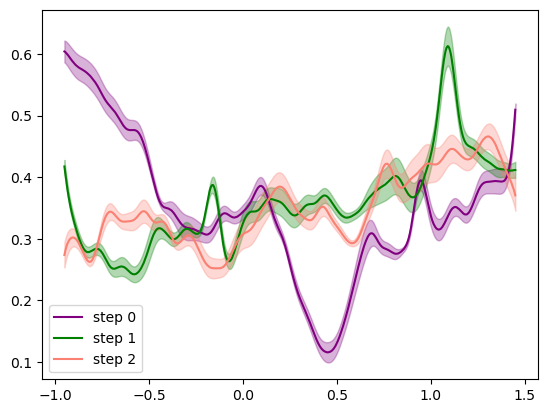

In [475]:
plt.close('all')
fig, ax = plt.subplots()

trial_idx = (df.trialerror == 0) & (df.step==0) 
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'step 0', 'purple')

trial_idx = (df.trialerror == 0) & (df.step==1) 
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'step 1', 'green')

trial_idx = (df.trialerror == 0) & (df.step==2) 
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'step 2', 'salmon')

ax.legend()

In [486]:
wave_freqs[idx]

array([11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21.])

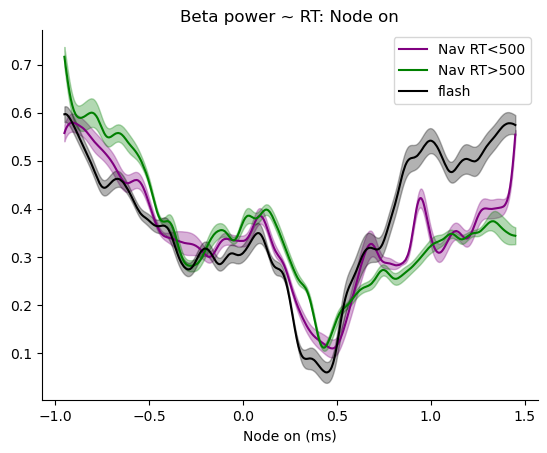

In [491]:
plt.close('all')
fig, ax = plt.subplots()

trial_idx = (df.trialerror == 0) & (df.step==0) & (df.RT<500)
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'Nav RT<500', 'purple')
df
trial_idx = (df.trialerror == 0) & (df.step==0) & (df.RT>500) 
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'Nav RT>500', 'green')

trial_idx = (df.trialerror == 1)
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'flash', 'k')

ax.legend()
plt.xlabel('Node on (ms)')
plt.title('Beta power ~ RT: Node on')
sns.despine()
plt.savefig('D:/Beta/beta power and RT, node on.png')

In [507]:
trial_idx

array([1])

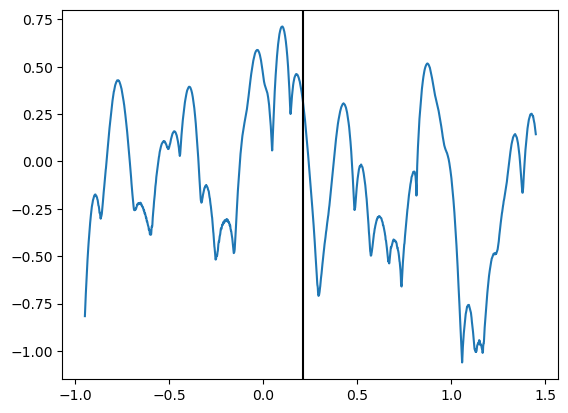

In [514]:
trial_idx = np.where((df.step==0) & (df.trial==6))[0][0]
plt.plot(time,(np.log10(node_wave_power[trial_idx,:]) - node_out)[idx,:][:,tt].mean(axis=0))
plt.axvline(df.RT.values[trial_idx]/1000,color='k')

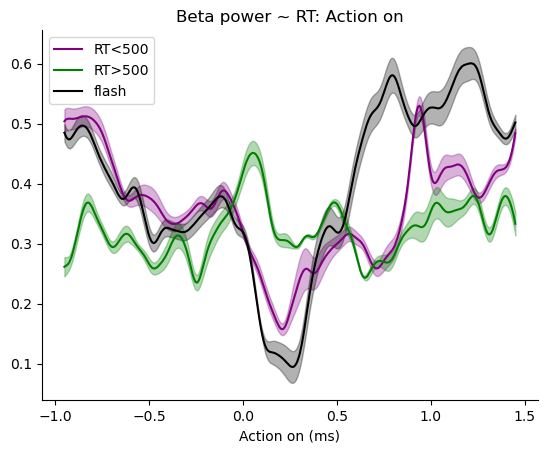

In [492]:
plt.close('all')
fig, ax = plt.subplots()

trial_idx = (df.trialerror == 0) & (df.step==0) & (df.RT<500)
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
plot_sem(time,data, ax, 'RT<500', 'purple')

trial_idx = (df.trialerror == 0) & (df.step==0) & (df.RT>500)
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
plot_sem(time,data, ax, 'RT>500', 'green')

trial_idx = (df.trialerror == 1)
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
plot_sem(time,data, ax, 'flash', 'k')

ax.legend()
plt.xlabel('Action on (ms)')
plt.title('Beta power ~ RT: Action on')
sns.despine()
plt.savefig('D:/Beta/beta power and RT, action on.png')

C:\Users\Admin\AppData\Local\Temp\ipykernel_32396\202578043.py:8: RuntimeWarning: Mean of empty slice.
  data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
C:\Users\Admin\anaconda3\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


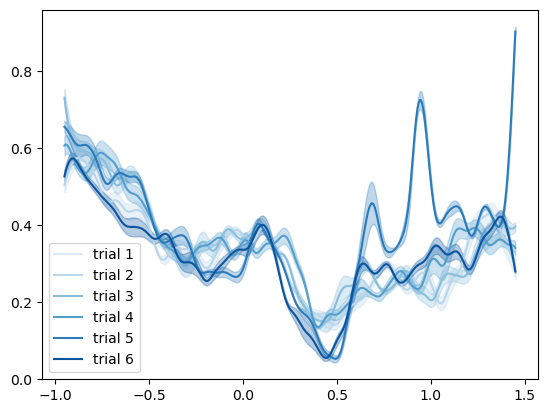

In [450]:
plt.close('all')
fig, ax = plt.subplots()

colors = sns.color_palette('Blues',6)

for ii in range(6):
    trial_idx = (df.trialerror == 0) & (df.step==0) & (df.blocktrialnumber==ii+2)
    data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
    plot_sem(time,data, ax, f'trial {ii+1}', colors[ii])


ax.legend()

C:\Users\Admin\AppData\Local\Temp\ipykernel_32396\2769246175.py:8: RuntimeWarning: Mean of empty slice.
  data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
C:\Users\Admin\anaconda3\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


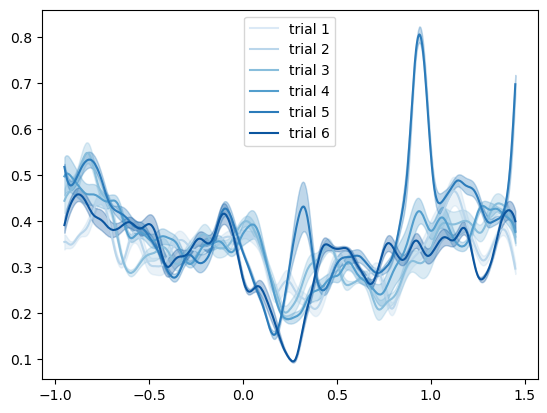

In [451]:
plt.close('all')
fig, ax = plt.subplots()

colors = sns.color_palette('Blues',6)

for ii in range(6):
    trial_idx = (df.trialerror == 0) & (df.step==0) & (df.blocktrialnumber==ii+2)
    data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
    plot_sem(time,data, ax, f'trial {ii+1}', colors[ii])


ax.legend()

In [371]:
idx = (wave_freqs>10) & (wave_freqs<22)

trial_idx = (df.trialerror == 0) & (df.step==0)
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]

trial_idx = (df.trialerror == 1)
flash_data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]

# planning
plan_data = (np.log10(plan_wave_power.mean(axis=0)) - plan_out)[idx,:][:,tt]

In [417]:
reward_df['delay_to_action']=reward_df.t_on.values-df.query('graph_distance==0').t_on.values

In [ ]:
mean_beta = np.log10(wave_power[:,idx,:][:,:,1000:1500].mean(axis=(1,2))) - out[idx,0].mean()

df['mean_beta'] = mean_beta

node_beta=df.query('(trialerror==0)').groupby('node')['mean_beta'].mean().values
plt.close('all')
sns.heatmap(data=node_beta.reshape((4,4)))

<Axes: xlabel='graph_distance', ylabel='mean_beta'>

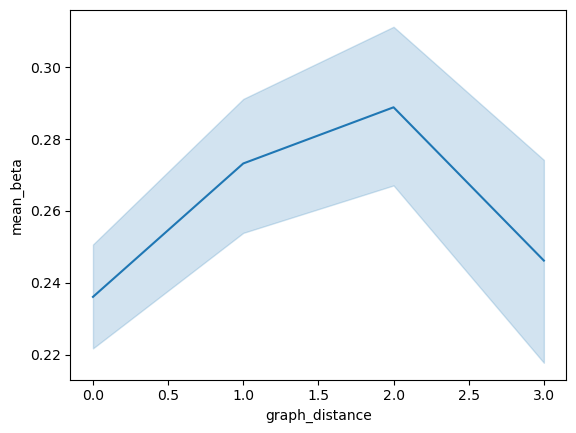

In [424]:
df['graph_distance']=np.clip(df['graph_distance'].values,0,3)
plt.close('all')
sns.lineplot(data=df,x='graph_distance',y='mean_beta')

In [427]:
value_spectrogram = np.zeros((4,98,2500))
trial_idx = (df.trialerror == 0) 
np.shape(np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)

(98, 2500)

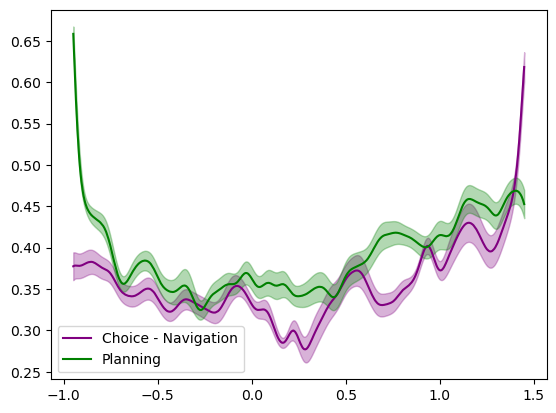

In [483]:
idx = (wave_freqs>10) & (wave_freqs<22)

trial_idx = (df.trialerror == 0) 
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]

plt.close('all')
fig, ax = plt.subplots()
plot_sem(time,data, ax, 'Choice - Navigation', 'purple')
# plot_sem(time,flash_data, ax, 'Choice - Flash', 'salmon')
plot_sem(time,plan_data, ax, 'Planning', 'green')

# plt.xlim(-0.5,0.5)
# plt.ylim(0,0.45)
ax.legend()

# plt.axvline(10)
# plt.axvline(22)

Text(0.5, 1.0, 'Action on')

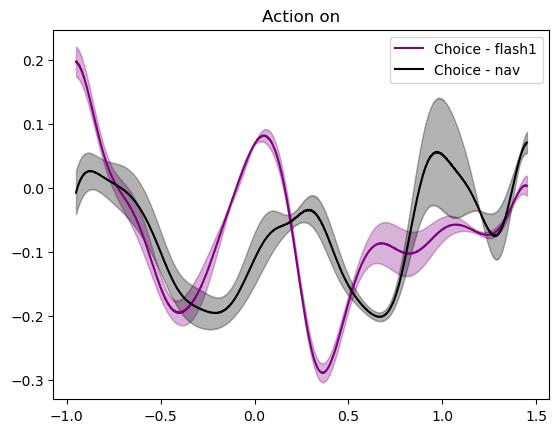

In [478]:
idx = (wave_freqs>10) & (wave_freqs<22)

plt.close('all')
fig, ax = plt.subplots()

trial_idx = (df.trialerror == 1) 
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
plot_sem(time,data, ax, 'Choice - flash1', 'purple')

# trial_idx = (df.trialerror == 1) & (df.blocktrialnumber==2)
# data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
# plot_sem(time,data, ax, 'Choice - flash2', 'green')

trial_idx = (df.trialerror == 0) & (df.step==0) 
data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
plot_sem(time,data, ax, 'Choice - nav', 'k')

# plt.xlim(-0.5,0.5)
# plt.ylim(0,0.45)
ax.legend()
plt.title('Action on')
# plt.axvline(10)
# plt.axvline(22)

In [460]:
mean_RT = df.query('step==0').groupby('trialerror')['RT'].mean().values

In [461]:
mean_RT

array([436.17276423, 192.3245614 ])

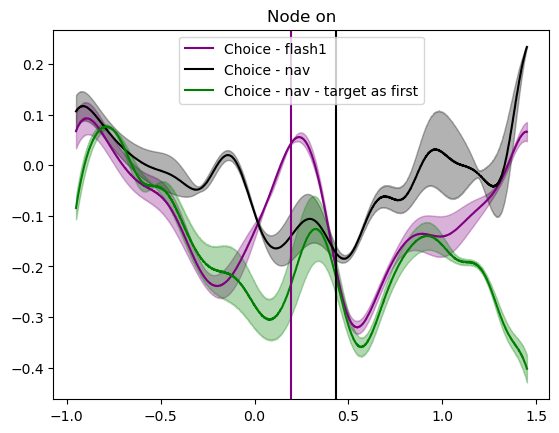

In [479]:
idx = (wave_freqs>10) & (wave_freqs<22)



plt.close('all')
fig, ax = plt.subplots()

trial_idx = (df.trialerror == 1) 
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'Choice - flash1', 'purple')

# trial_idx = (df.trialerror == 1) & (df.blocktrialnumber==2)
# data = (np.log10(wave_power[trial_idx,:].mean(axis=0)) - out)[idx,:][:,tt]
# plot_sem(time,data, ax, 'Choice - flash2', 'green')

trial_idx = (df.trialerror == 0) & (df.step==0) & ~np.isin(df.node.values,[1,7,8,14])
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'Choice - nav', 'k')


trial_idx = (df.trialerror == 0) & (df.step==0) & np.isin(df.node.values,[1,7,8,14])
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'Choice - nav - target as first', 'green')

# plt.xlim(-0.5,0.5)
# plt.ylim(0,0.45)
ax.legend()
plt.title('Node on')
plt.axvline(mean_RT[0]/1000,color='k')
plt.axvline(mean_RT[1]/1000,color='purple')

<Axes: xlabel='RT', ylabel='Count'>

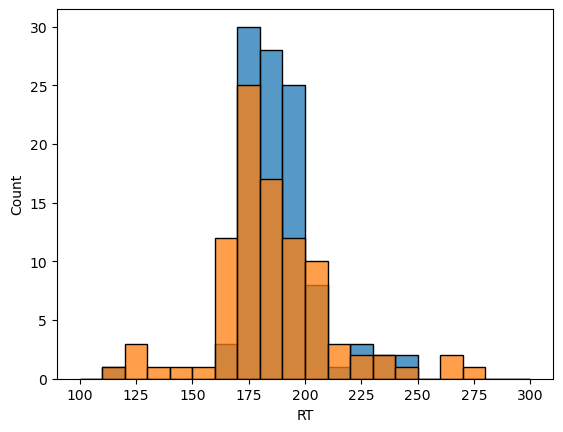

In [444]:
plt.close('all')
sns.histplot(data=df.query('(trialerror==1)&(blocktrialnumber==1)'),x='RT',binrange=[100,300],bins=20)
sns.histplot(data=df.query('(trialerror==1)&(blocktrialnumber==2)'),x='RT',binrange=[100,300],bins=20)

Text(0.5, 1.0, 'Node on')

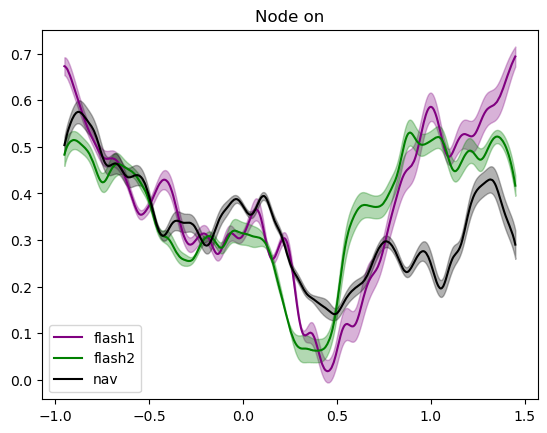

In [438]:
idx = (wave_freqs>10) & (wave_freqs<22)

plt.close('all')
fig, ax = plt.subplots()

trial_idx = (df.trialerror == 1) & (df.blocktrialnumber==1)
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'flash1', 'purple')

trial_idx = (df.trialerror == 1) & (df.blocktrialnumber==2)
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'flash2', 'green')

trial_idx = (df.trialerror == 0) & (df.step==0) & (df.blocktrialnumber==3)
data = (np.log10(node_wave_power[trial_idx,:].mean(axis=0)) - node_out)[idx,:][:,tt]
plot_sem(time,data, ax, 'nav', 'k')

# plt.xlim(-0.5,0.5)
# plt.ylim(0,0.45)
ax.legend()

# plt.axvline(10)
# plt.axvline(22)
plt.title('Node on')

In [ ]:
# RT look at if beta is correlated with reaction time

In [31]:
from LFP import preprocess_LFP

In [517]:
def epoch_aligned_lfp(date,df,window,channel):
    
    timestamps, lfpData = load_data.load_LFP(date)
    lfpFile = h5py.File(f'D:/Teleworld/bart_I/raw/spikes/Bart_TeleWorld_v13_{date}-spikes.mat', 'r')

    aligned_lfp = np.zeros((len(df),window[1]-window[0]))  # 1 if happened during ITI, 0 if during a trial
    
    for ii in range(len(df)):

        on = df.iloc[ii].t_on.astype(float)
        idx = (timestamps>on+window[0]) & (timestamps<on+window[1])
        aligned_lfp[ii,:] = lfpData[idx,channel].T.astype(np.float32)
    
    return aligned_lfp

In [516]:
def wavelet_spectrogram(lfp, freqs, wavelet = 'cmor1.5-1.0', fs=1000):

    # using complex Morlet with bandwidth=1.5, center freq=1.0

    # notch filter 60hz and harmonics
    lfp_filt = preprocess_LFP(lfp)
    detrended = detrend(lfp_filt)  
    
    # Convert frequencies to scales for Morlet wavelet in pywt
    center_freq = pywt.central_frequency(wavelet)
    scales = center_freq * fs / freqs
    
    # Compute the Continuous Wavelet Transform (CWT)
    coeffs, frequencies = pywt.cwt(detrended, scales, wavelet, sampling_period=1/fs)
    
    # Compute power (magnitude squared of coefficients)
    phase = np.angle(coeffs)   # instantaneous phase
    power = np.abs(coeffs) ** 2

    return frequencies, coeffs, phase.astype(np.float32), power.astype(np.float32)

In [ ]:
def coherogram(sig1, sig2, window = 1000, slide=25, fs=1000):
    
    timestamps = np.arange(window, sig1.shape[1]-window+slide, slide)
    
    Cxy = np.zeros((sig1.shape[0],len(timestamps),251))

    for trial in tqdm(range(sig1.shape[0])):

        for ii, tt in enumerate(timestamps):
        
            f_coh, Cxy[trial,ii,:] = coherence(sig1[trial,tt-window:tt+window],sig2[trial,tt-window:tt+window],
                                               fs=fs,nperseg=fs/2,noverlap=fs/2*0.75)

    return f_coh, Cxy

Text(0.5, 1.0, 'Periodic component (FOOOF)')

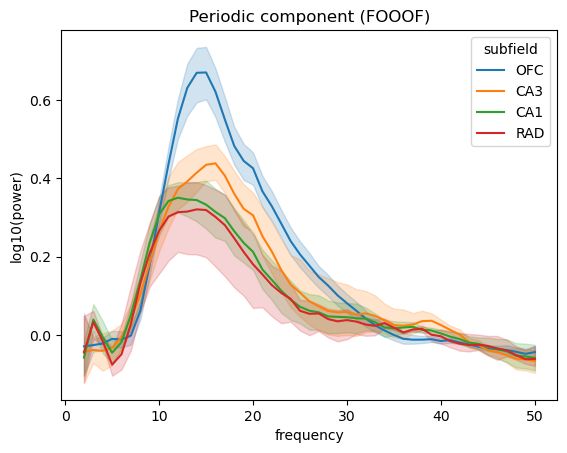

In [2]:
# get flattened psd for all plexon recordings, inluding all channels

all_spec = pd.DataFrame()

for date in ['031723','032823','033123', '032023', '040423', '040723']:
    
    flat_spec = np.load(f'D:/Alpha/Session {date} fooof flat psd.npy')
    nwbfile = load_data.load_nwbfile('Bart',date) 
    unitNames = nwbfile.units.to_dataframe()
    probes = unitNames.drop_duplicates('probe')
    subfield_spec = []   # collect rows here
    
    for p in probes.probe.unique():
        # subset for this probe
        sub_df = probes.query("probe == @p")
    
        # channel numbers belonging to this probe
        probe_channels = np.arange(sub_df.start_channel.min() - 1,
                                   sub_df.end_channel.max())
    
        # subfield labels for each channel
        # IMPORTANT: must align channels with sub_df rows
        channel_subfield = []
        for _, row in sub_df.iterrows():
            chs = np.arange(row.start_channel - 1, row.end_channel)
            channel_subfield.extend([row.subfield] * len(chs))
    
        channel_subfield = np.array(channel_subfield)
    
        # extract the spectrum for these channels
        spec_subset = flat_spec[probe_channels, :]      # shape: (#channels, #freqs)
        n_channels, n_freqs = spec_subset.shape
    
        # real frequency values (f_2, f_3, f_4, ...)
        frequency_vals = np.arange(2, 2 + n_freqs)
    
        # build a long-format dataframe for this probe
        df = pd.DataFrame({
            "session": date,
            "probe": np.repeat(p, n_channels * n_freqs),
            "channel": np.repeat(probe_channels, n_freqs),
            "subfield": np.repeat(channel_subfield, n_freqs),
            "frequency": np.tile(frequency_vals, n_channels),
            "power": spec_subset.flatten()
        })
    
        subfield_spec.append(df)
    
    # concatenate across all probes
    subfield_spec = pd.concat(subfield_spec, ignore_index=True)
    all_spec = pd.concat([all_spec,subfield_spec])

all_spec.to_pickle("D:/Alpha/fooof_flatten_psd.pkl")

alpha_beta = all_spec.query('(frequency>10)&(frequency<25)').groupby(['session', 'probe', 'channel'])['power'].mean().reset_index()

# get index of max power per group
idx = alpha_beta.groupby(['session','probe'])['power'].idxmax()

# select those rows
df_max = alpha_beta.loc[idx].reset_index(drop=True)
df_max

# merge to keep only rows with matching session, probe, channel
subset = all_spec.merge(
    df_max[['session', 'probe', 'channel']],
    on=['session', 'probe', 'channel'],
    how='inner'
)

subset.reset_index(drop=True, inplace=True)


plt.close('all')
sns.lineplot(data=all_spec[all_spec.session=='031723'],x='frequency',y='power',hue='subfield')
plt.ylabel('log10(power)')
plt.title('Periodic component (FOOOF)')
# plt.savefig('D:/Alpha/fooof_flatten_psd')

plt.close('all')
sns.lineplot(data=subset,x='frequency',y='power',hue='subfield')
plt.ylabel('log10(power)')
plt.title('Periodic component (FOOOF)')
# plt.savefig('D:/Alpha/fooof_flatten_psd')

In [24]:
# get flattened psd for all plexon recordings, inluding all channels, conditioned on value

all_spec = []

dates = ['031723','032823','033123','032023','040423','040723']

for date in dates:

    freqs, flat_spec = get_flattened_psd(date)
    nwbfile = load_data.load_nwbfile('Bart', date)

    unitNames = nwbfile.units.to_dataframe()
    probes = unitNames.drop_duplicates('probe')

    for p in probes.probe.unique():

        sub_df = probes.query("probe == @p")

        probe_channels = np.arange(
            sub_df.start_channel.min() - 1,
            sub_df.end_channel.max()
        )

        # build channel → subfield mapping
        channel_subfield = []
        for _, row in sub_df.iterrows():
            chs = np.arange(row.start_channel - 1, row.end_channel)
            channel_subfield.extend([row.subfield] * len(chs))

        channel_subfield = np.array(channel_subfield)

        for vv in range(flat_spec.shape[0]):

            spec_subset = flat_spec[vv, probe_channels, :]
            n_channels, n_freqs = spec_subset.shape

            df = pd.DataFrame({
                "session": date,
                "probe": p,
                "value": vv,
                "channel": np.repeat(probe_channels, n_freqs),
                "subfield": np.repeat(channel_subfield, n_freqs),
                "frequency": np.tile(freqs[:n_freqs], n_channels),
                "power": spec_subset.flatten()
            })

            all_spec.append(df.query('frequency<50'))

# concatenate everything
all_spec = pd.concat(all_spec, ignore_index=True)
all_spec.to_pickle("D:/Alpha/fooof_flatten_psd_conditioned_on_value.pkl")

  1%|          | 1/192 [00:00<00:46,  4.15it/s]


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a low

  1%|          | 2/192 [00:00<00:48,  3.91it/s]


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a low

  2%|▏         | 3/192 [00:00<00:49,  3.81it/s]

...


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a low

 99%|█████████▉| 191/192 [01:09<00:00,  2.53it/s]


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a low

100%|██████████| 192/192 [01:10<00:00,  2.74it/s]


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.


FOOOF WARNING: Lower-bound peak width limit is < or ~= the frequency resolution: 0.50 <= 2.00
	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a low

In [ ]:
# look at gamma band filtered power for each epoch, node onset or reward
# phase delay?

In [ ]:
# have a pipeline to process all frequency bands
# filtered band power
# cross-trial phase alignment
# coherence
# phase lag/synchronization
# phase locking
# phase precession

In [6]:
all_spec = pd.read_pickle("D:/Alpha/fooof_flatten_psd_conditioned_on_value.pkl")

In [ ]:
# look at instantaneous power to better locate beta oscillation in time for phase-locking analysis

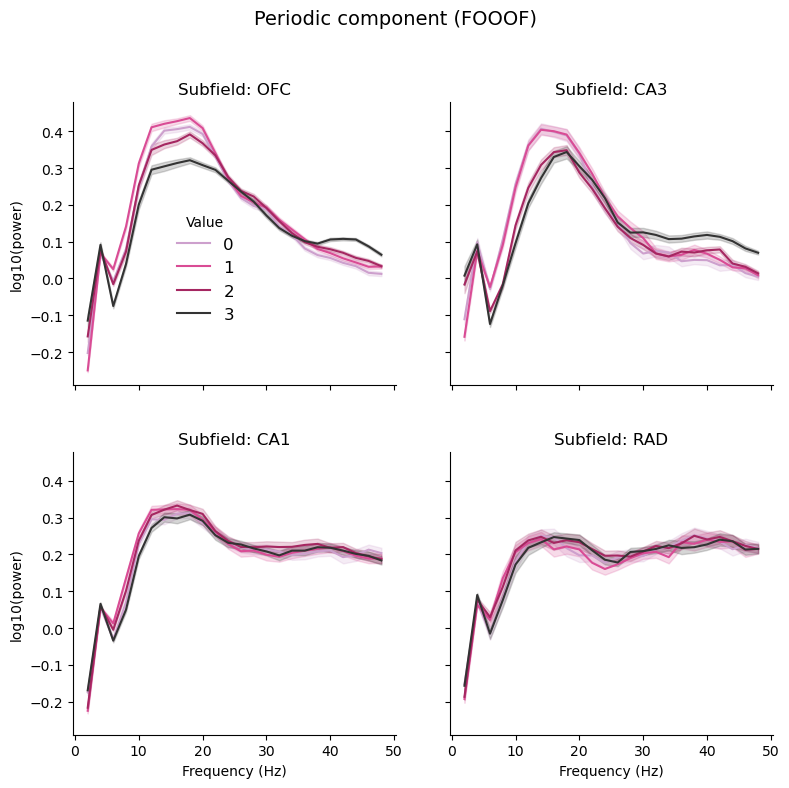

In [52]:
# look at how value modulates alpha/beta power in each subfield

choice_df = nwbfile.intervals['action_on'].to_dataframe()
choice_df['value'] = np.maximum(0,3-choice_df['graph_distance'].values)

plt.close('all')

subfields = ['OFC', 'CA3', 'CA1', 'RAD']

fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
for ax, sf in zip(axes, subfields):

    sns.lineplot(
        data=all_spec[(all_spec.subfield == sf)],
        x='frequency',
        y='power',
        hue='value',          # since you renamed condition → value
        ax=ax
    )

    ax.set_title(f'Subfield: {sf}')
    ax.set_ylabel('log10(power)')
    ax.set_xlabel('Frequency (Hz)')

# put legend only once (cleaner)
axes[0].legend(title='Value',frameon=False,fontsize=12,loc=(0.3,0.2))
for ax in axes[1:]:
    ax.get_legend().remove()

fig.suptitle('Periodic component (FOOOF)', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3, w_pad=3)
sns.despine()
# optional save
# fig.savefig('D:/Alpha/fooof_flatten_psd_value.png', dpi=300)


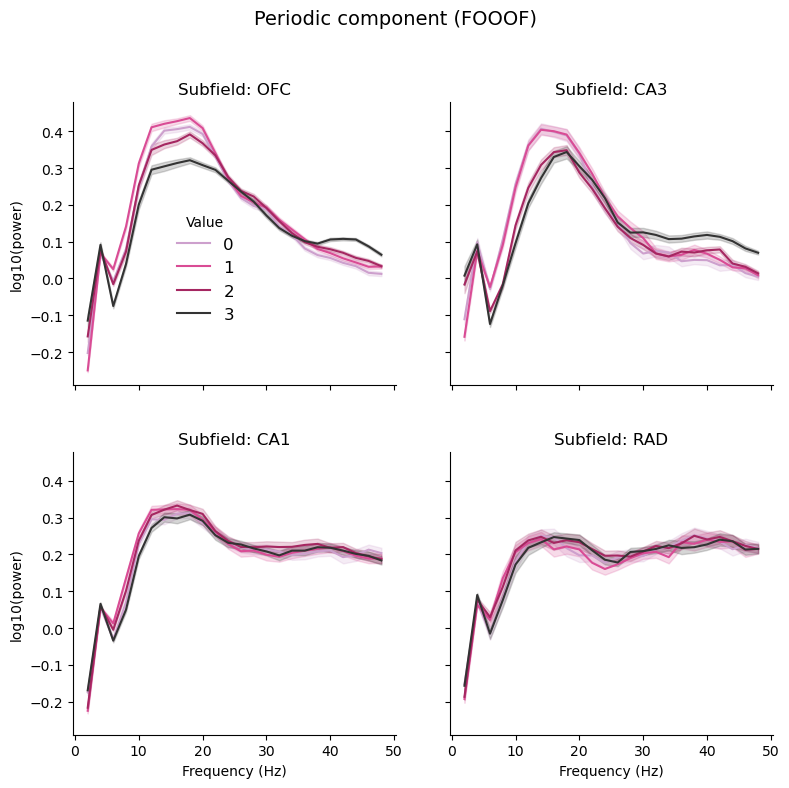

In [52]:
# look at whether there is difference between flash and navigation

choice_df = nwbfile.intervals['action_on'].to_dataframe()
choice_df['value'] = np.maximum(0,3-choice_df['graph_distance'].values)

plt.close('all')

subfields = ['OFC', 'CA3', 'CA1', 'RAD']

fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
for ax, sf in zip(axes, subfields):

    sns.lineplot(
        data=all_spec[(all_spec.subfield == sf)],
        x='frequency',
        y='power',
        hue='value',          # since you renamed condition → value
        ax=ax
    )

    ax.set_title(f'Subfield: {sf}')
    ax.set_ylabel('log10(power)')
    ax.set_xlabel('Frequency (Hz)')

# put legend only once (cleaner)
axes[0].legend(title='Value',frameon=False,fontsize=12,loc=(0.3,0.2))
for ax in axes[1:]:
    ax.get_legend().remove()

fig.suptitle('Periodic component (FOOOF)', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3, w_pad=3)
sns.despine()
# optional save
# fig.savefig('D:/Alpha/fooof_flatten_psd_value.png', dpi=300)


In [109]:
def get_highest_power_channel(df, ses):
    
    session_df = df[
        (df['frequency'] > 10) &
        (df['frequency'] < 30) &
        (df['session'] == ses)
    ]
    
    channels = (
        session_df
        .groupby('channel', as_index=False)['power']
        .max()
        .merge(
            session_df[['probe','channel','subfield']].drop_duplicates(),
            on='channel',
            how='left'
        )
    )

    return channels.loc[channels.groupby('probe')['power'].idxmax()]

100%|██████████| 6/6 [00:00<00:00, 213.74it/s]


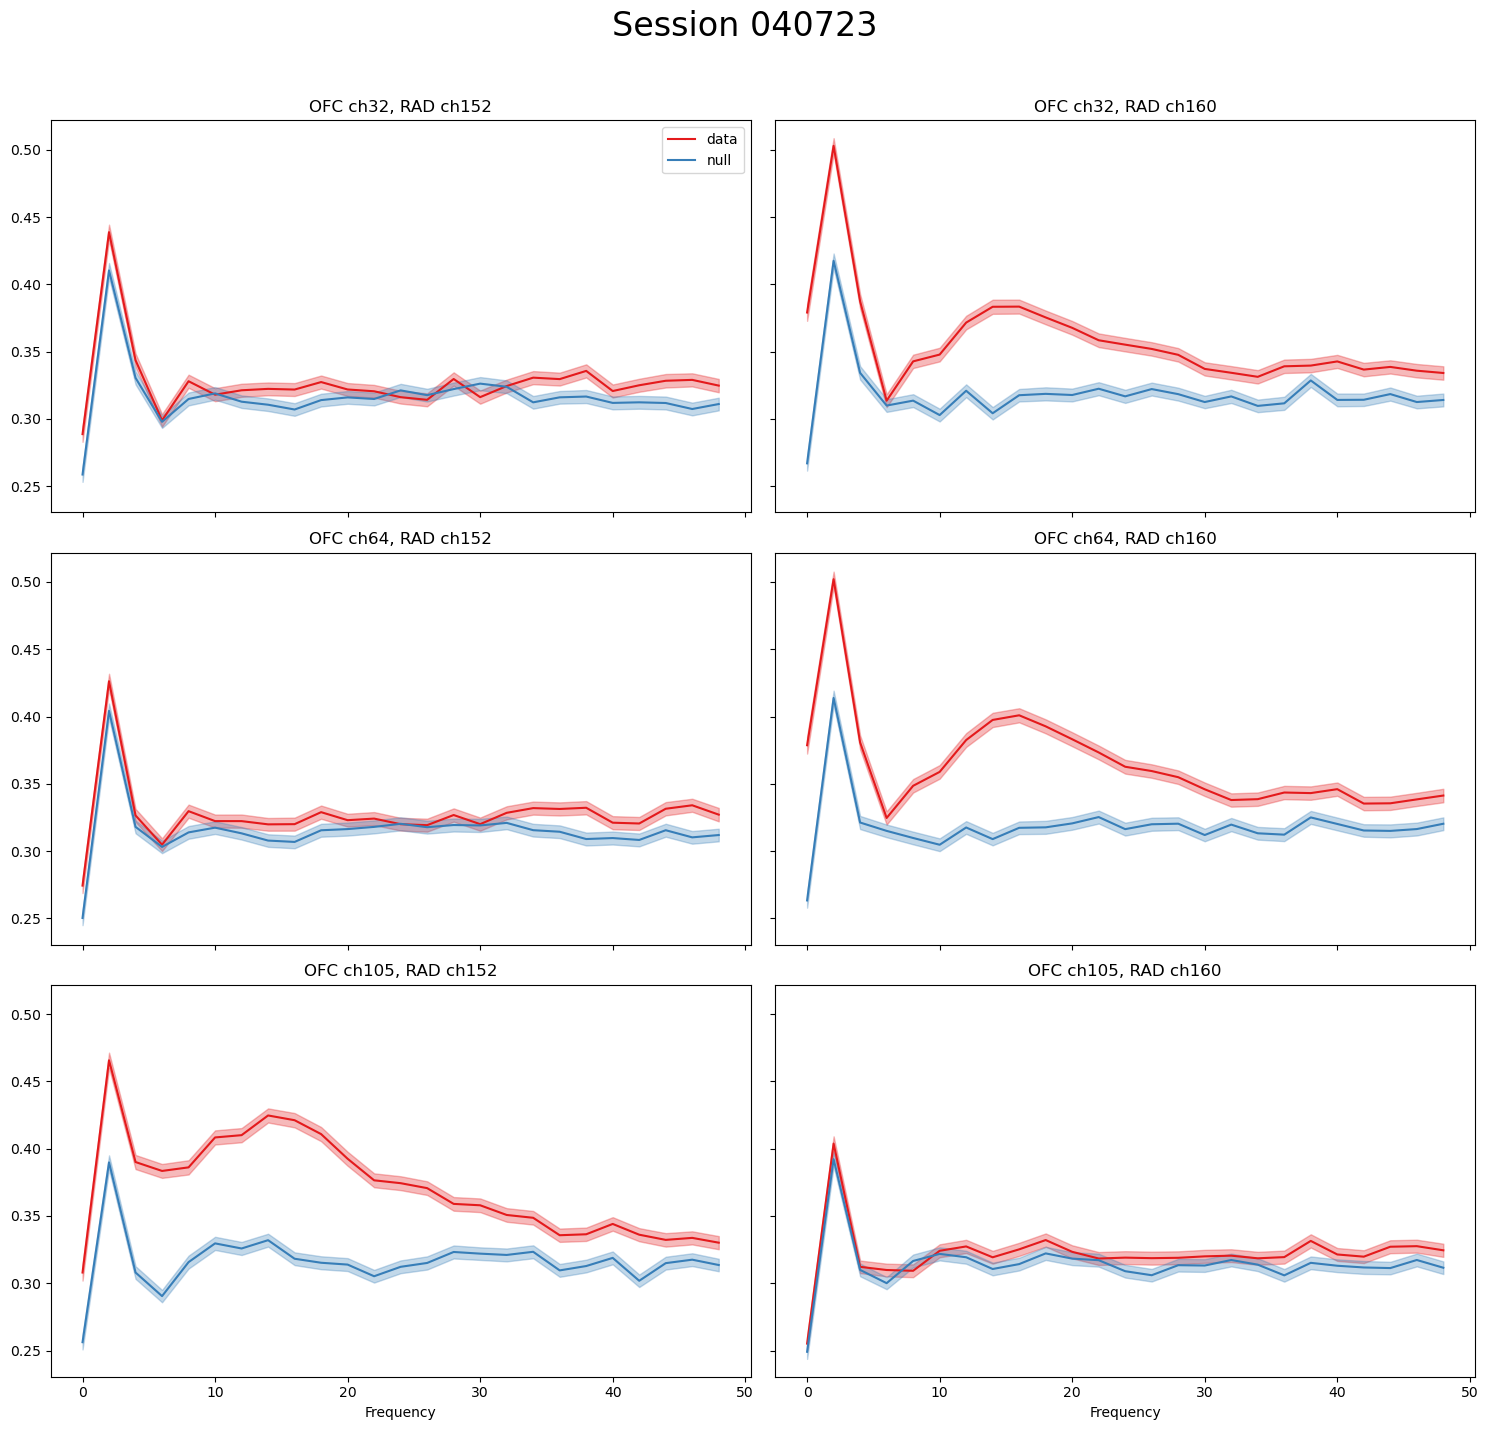

In [176]:
# get lfp aligned to behavior epochs, used for both psd and coherence
for date in ['040423','040723']:

    nwbfile = load_data.load_nwbfile('Bart',date) 
    
    query = 'trialerror==0'
    choice_df = nwbfile.intervals['action_on'].to_dataframe().query(query)
    choice_df['value'] = np.maximum(0,3-choice_df['graph_distance'].values)
    action_aligned = epoch_aligned_lfp(date,choice_df,[-250,750])
    
    # get channel number with the highest alpha/beta band power from each probe in a given session to calculate coherence
    channels = get_highest_power_channel(all_spec, date)
    ofc_channels = channels.loc[channels.subfield == 'OFC', 'channel'].values
    hpc_channels = channels.loc[channels.subfield != 'OFC', 'channel'].values
    pairs = list(product(ofc_channels, hpc_channels))

    # get coherence
    fs=1000
    nperseg = fs*0.5 #action_aligned.shape[2]*0.8
    noverlap = nperseg*0.75
    
    pairs = list(product(ofc_channels, hpc_channels))   
    n_trials = action_aligned.shape[0]
    n_freqs = int(nperseg // 2 + 1)
    n_pairs = len(pairs)
    
    ofc_hpc_coh_all = np.zeros((n_pairs, n_trials, n_freqs))
    ofc_hpc_coh_null_all = np.zeros_like(ofc_hpc_coh_all)
    
    # shuffled indices for null
    shuffled_trial_idx = np.random.permutation(n_trials)
    
    # Loop through all pairs
    for i, (ofc_ch, hpc_ch) in enumerate(tqdm(pairs)):
        for trial in range(n_trials):
            x = action_aligned[trial, ofc_ch, :]
            y = action_aligned[trial, hpc_ch, :]
    
            # actual coherence
            _, ofc_hpc_coh_all[i, trial, :] = coherence(
                x, y, fs=fs, nperseg=nperseg, noverlap=noverlap
            )
    
            # trial-shuffled coherence (null)
            y_null = action_aligned[shuffled_trial_idx[trial], hpc_ch, :]
            _, ofc_hpc_coh_null_all[i, trial, :] = coherence(
                x, y_null, fs=fs, nperseg=nperseg, noverlap=noverlap
            )
    
    
    plt.close('all')
    fig, axes = plt.subplots(len(ofc_channels),len(hpc_channels),figsize=(15,15),sharex=True, sharey=True)
    
    for ii, (ofc_ch, hpc_ch) in enumerate(tqdm(pairs)):
        
        r,c = np.divmod(ii,len(hpc_channels))
        plot_sem(f_coh[f_coh<50], ofc_hpc_coh_all[ii,:,:][:,f_coh<50], axes[r,c], 0, 'data', colors='Set1') 
        plot_sem(f_coh[f_coh<50], ofc_hpc_coh_null_all[ii,:,:][:,f_coh<50], axes[r,c], 1, 'null', colors='Set1') 

        subfield = channels.query('channel==@hpc_ch').subfield.values[0]
        axes[r,c].set_title(f'OFC ch{pairs[ii][0]}, {subfield} ch{pairs[ii][1]}')
        
        if r==2:
            axes[r,c].set_xlabel('Frequency')
        
    axes[0,0].legend()
    
    plt.tight_layout(rect=[0,0,1,0.9])
    plt.suptitle(f'Session {date}',y=0.95,fontsize=24)
    plt.savefig(f'D:/Alpha/Coherence, Session {date}')

In [ ]:
# visually inspect psd of the highest channel
temp = all_spec[(all_spec.channel==69)&(all_spec.session=='031723')] 
plt.close('all')
sns.lineplot(data=temp, x='frequency',y='power',hue='value')


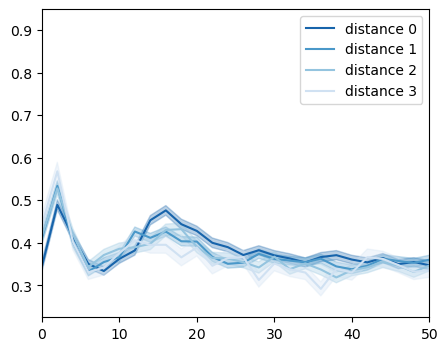

In [118]:
plt.close('all')
fig, ax = plt.subplots(figsize=(5,4))
for ii in range(4):
    plot_sem(f_coh,Cxy_reward[action_df.graph_distance.values==ii,:],ax,ii,f"distance {ii}")
plt.xlim(0,50)
# plt.ylim(0.3,0.55)
plt.legend()

In [72]:
# get coherogram
f_coh, ofc_hpc_coh = coherogram(node_aligned[:,95,:],node_aligned[:,187,:])

100%|██████████| 1499/1499 [00:44<00:00, 33.32it/s]


In [116]:
# get imaginery coherence using csd, since signal.coherence only returns squared magnitude
from scipy.signal import csd, welch

fs = 1000
n_trials = action_aligned.shape[0]

nperseg = int(fs * 0.5)
noverlap = int(nperseg * 0.75)

Cxy_imag = np.zeros((n_trials, 251))
Cxy_real = np.zeros((n_trials, 251))

for trial in tqdm(range(n_trials)):

    x = action_aligned[trial, 95, :]
    y = action_aligned[trial, 187, :]

    # cross-spectrum
    f, Pxy = csd(
        x, y,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    # auto-spectra
    _, Pxx = welch(
        x,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    _, Pyy = welch(
        y,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    # coherency
    coherency = Pxy / np.sqrt(Pxx * Pyy)

    # imaginary coherence
    Cxy_imag[trial, :] = np.imag(coherency)
    Cxy_real[trial,:] = np.real(coherency)


100%|██████████| 1499/1499 [00:01<00:00, 1342.01it/s]


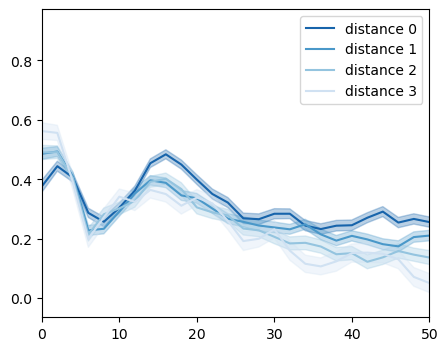

In [119]:
plt.close('all')
fig, ax = plt.subplots(figsize=(5,4))
for ii in range(4):
    plot_sem(f_coh,Cxy_real[action_df.graph_distance.values==ii,:],ax,ii,f"distance {ii}")
plt.xlim(0,50)
# plt.ylim(0.3,0.55)
plt.legend()

(array([ 17.,  58., 161., 307., 336., 284., 186., 108.,  34.,   8.]),
 array([-0.5743608 , -0.45605399, -0.33774719, -0.21944038, -0.10113358,
         0.01717323,  0.13548004,  0.25378684,  0.37209365,  0.49040045,
         0.60870726]),
 <BarContainer object of 10 artists>)

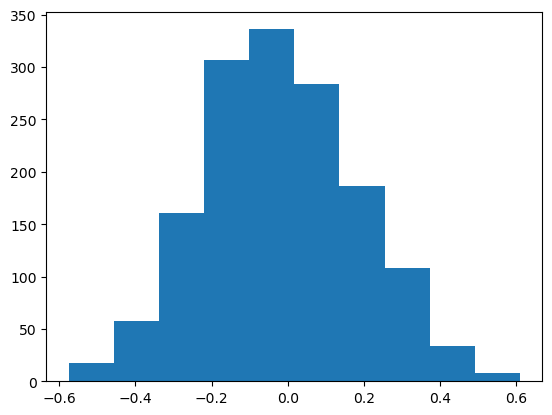

In [123]:
plt.hist(Cxy_imag[:,(f_coh>10)&(f_coh<25)].mean(axis=1))

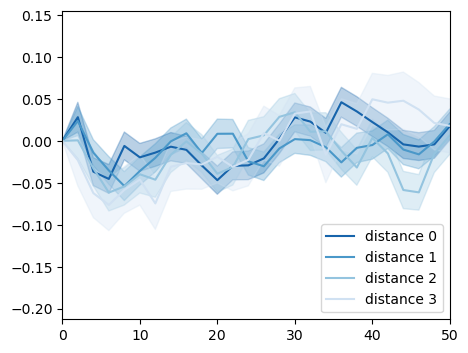

In [120]:
plt.close('all')
fig, ax = plt.subplots(figsize=(5,4))
for ii in range(4):
    plot_sem(f_coh,Cxy_imag[action_df.graph_distance.values==ii,:],ax,ii,f"distance {ii}")
plt.xlim(0,50)
# plt.ylim(0.3,0.55)
plt.legend()

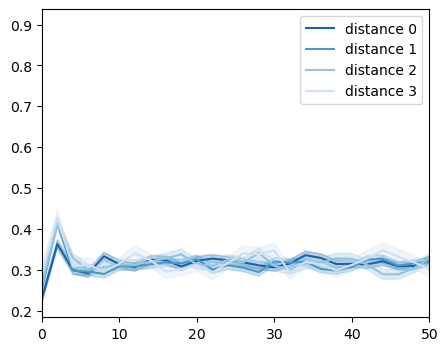

In [109]:
plt.close('all')
fig, ax = plt.subplots(figsize=(5,4))
for ii in range(4):
    plot_sem(f_coh,Cxy_reward[action_df.graph_distance.values==ii,:],ax,ii,f"distance {ii}")
plt.xlim(0,50)
# plt.ylim(0.3,0.55)
plt.legend()

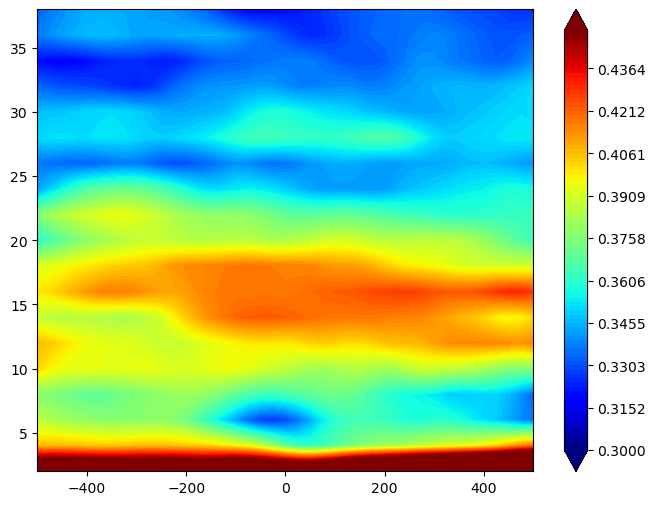

In [76]:
plt.close('all')
fig, ax = plt.subplots(figsize=(8,6))
window = 500
slide=25
idx = (node_df.trialerror==0) & (node_df.step==0) #& (node_df.node!=node_df.target)
timestamps = np.arange(-1000+window, 1000-window+slide, slide)

c = ax.contourf(
    timestamps,
    f_coh[(f_coh<40)&(f_coh>0)],
    ofc_hpc_coh[idx,:,:].mean(axis=0).T[(f_coh<40)&(f_coh>0),:],
    cmap='jet',
    levels = np.linspace(0.3, 0.45, 100),
    extend='both'
)
plt.colorbar(c,ax=ax)

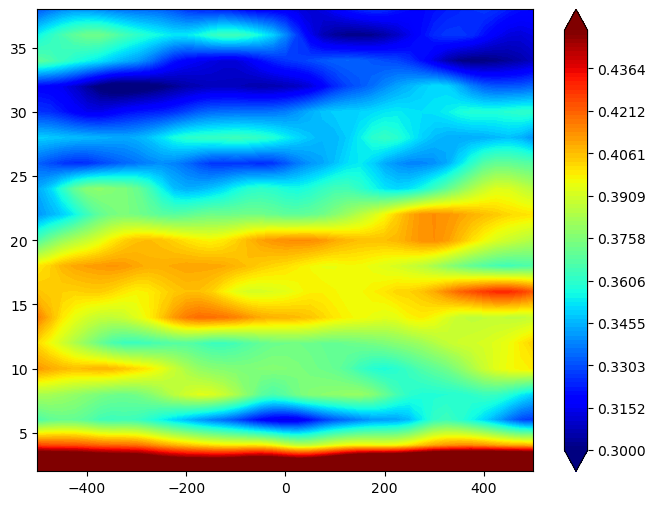

In [83]:
plt.close('all')
fig, ax = plt.subplots(figsize=(8,6))
window = 500
slide=25
idx = (node_df.trialerror==0) & (node_df.graph_distance==3) #& (node_df.node!=node_df.target)
timestamps = np.arange(-1000+window, 1000-window+slide, slide)

c = ax.contourf(
    timestamps,
    f_coh[(f_coh<40)&(f_coh>0)],
    ofc_hpc_coh[idx,:,:].mean(axis=0).T[(f_coh<40)&(f_coh>0),:],
    cmap='jet',
    levels = np.linspace(0.3, 0.45, 100),
    extend='both'
)
plt.colorbar(c,ax=ax)

In [53]:
def coherogram(sig1, sig2, window = 500, slide=25, fs=1000):
    
    timestamps = np.arange(window, sig1.shape[1]-window+slide, slide)
    
    Cxy = np.zeros((sig1.shape[0],len(timestamps),251))

    for trial in tqdm(range(sig1.shape[0])):

        for ii, tt in enumerate(timestamps):
        
            f_coh, Cxy[trial,ii,:] = coherence(sig1[trial,tt-window:tt+window],sig2[trial,tt-window:tt+window],fs=fs,nperseg=fs/2,noverlap=fs/2*0.75)

    return f_coh, Cxy